In [1]:
%%capture
## [TEMPLATE BEGIN]
## おまじない：実行中のノートブック名からOUTPUT_DIRを決めるコード
from pathlib import Path
from IPython import get_ipython; ip = get_ipython()
if '__vsc_ipynb_file__' in ip.user_ns:
    ## VS Codeで実行されている場合
    THIS_NOTEBOOK_PATH = Path(ip.user_ns['__vsc_ipynb_file__'])
else:
    !pip install ipynbname
    import ipynbname; THIS_NOTEBOOK_PATH = Path(ipynbname.path())
    if "%2F" in THIS_NOTEBOOK_PATH.stem:
        ## Google Colabで実行されている場合
        colab_ip = %system hostname -I   # uses colab magic to get list from bash
        colab_ip = colab_ip[0].strip()   # returns "172.28.0.12"
        colab_port = 9000                # could use 6000, 8080, or 9000
        import requests
        filename = requests.get(f"http://{colab_ip}:{colab_port}/api/sessions").json()[0]["name"]
        THIS_NOTEBOOK_PATH = Path(filename)
    else:
        ## それ以外の場合
        THIS_NOTEBOOK_PATH = THIS_NOTEBOOK_PATH

OUTPUT_DIR = Path("figures") / THIS_NOTEBOOK_PATH.stem
## [TEMPLATE END]

In [2]:
print("File output directory:", OUTPUT_DIR)
# Create the output directory if it does not exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

File output directory: figures/_logsumexp



[notice] A new release of pip is available: 23.2.1 -> 24.2
[notice] To update, run: pip install --upgrade pip


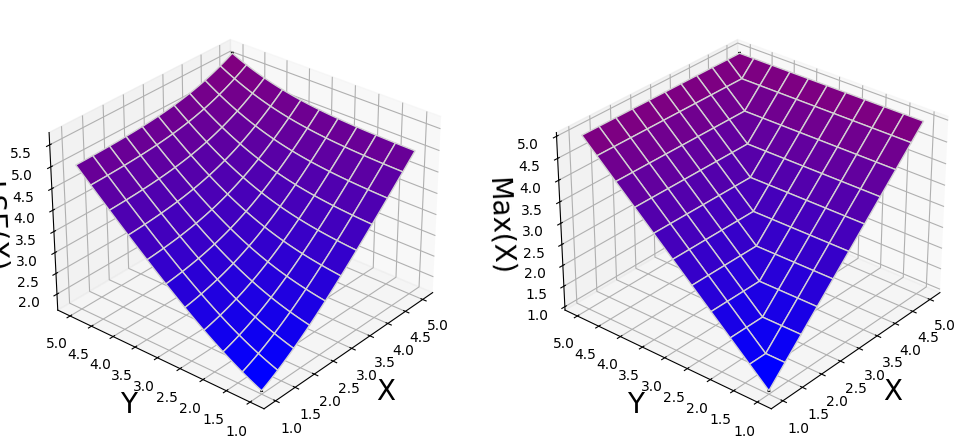

Sequence: [1, 10, 3]
  Log-Sum-Exponential (LSE): 10.001034756224715
  Max: 10
--------------------------------------------------
Sequence: [2, 5, 8, 0]
  Log-Sum-Exponential (LSE): 8.051264512987181
  Max: 8
--------------------------------------------------
Sequence: [7, 1, 9, 4]
  Log-Sum-Exponential (LSE): 9.133138921873602
  Max: 9
--------------------------------------------------


In [8]:
# Install necessary libraries
!pip install matplotlib numpy scipy

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.special import logsumexp
from matplotlib.colors import LinearSegmentedColormap

# Output directory already defined as OUTPUT_DIR in your environment
# Ensure that OUTPUT_DIR is of type pathlib.Path in the previous cell

# Custom colormap using blue and purple from your predefined palette
colors = ["#0000FF", "#800080"]  # Blue and Purple
custom_cmap = LinearSegmentedColormap.from_list("blue_purple", colors)

# Generate data for 3D surface plots
x = np.linspace(1, 5, 50)
y = np.linspace(1, 5, 50)
X, Y = np.meshgrid(x, y)

# LSE function
Z_lse = np.log(np.exp(X) + np.exp(Y))

# Max function
Z_max = np.maximum(X, Y)

# Values for y = x line
xy_line = np.linspace(1, 5, 50)

# Plotting
fig = plt.figure(figsize=(12, 6))

# Left plot (LSE)
ax1 = fig.add_subplot(121, projection='3d')
# Coarser mesh with increased rstride and cstride
surf1 = ax1.plot_surface(X, Y, Z_lse, cmap=custom_cmap, rstride=5, cstride=5, edgecolor='lightgray')
ax1.set_xlabel('X', fontsize=20)
ax1.set_ylabel('Y', fontsize=20)
ax1.set_zlabel('LSE(X)', fontsize=20)
# Rotate the plot: Elevation and Azimuth angles
ax1.view_init(elev=30, azim=220)
# Plot the y = x line on the surface (black color)
ax1.plot(xy_line, xy_line, np.log(2 * np.exp(xy_line)), color='black', linewidth=2)

# Right plot (Max)
ax2 = fig.add_subplot(122, projection='3d')
# Coarser mesh with increased rstride and cstride
surf2 = ax2.plot_surface(X, Y, Z_max, cmap=custom_cmap, rstride=5, cstride=5, edgecolor='lightgray')
ax2.set_xlabel('X', fontsize=20)
ax2.set_ylabel('Y', fontsize=20)
ax2.set_zlabel('Max(X)', fontsize=20)
# Rotate the plot: Elevation and Azimuth angles
ax2.view_init(elev=30, azim=220)
# Plot the y = x line on the surface (black color)
ax2.plot(xy_line, xy_line, xy_line, color='black', linewidth=2)

# Save the figure
output_file = OUTPUT_DIR / "lse_max_surface_plot_with_y_equals_x_lines.png"
plt.savefig(output_file, bbox_inches='tight', pad_inches=0)

# Show the plot
plt.show()

# Examples of log-sum-exponential and max function for multiple sequences
sequences = [[1, 10, 3], [2, 5, 8, 0], [7, 1, 9, 4]]  # Replace/add your own sequences here

for seq in sequences:
    # Log-Sum-Exponential for each sequence
    lse_value = logsumexp(seq)
    # Max function for each sequence
    max_value = max(seq)
    
    print(f"Sequence: {seq}")
    print(f"  Log-Sum-Exponential (LSE): {lse_value}")
    print(f"  Max: {max_value}")
    print("-" * 50)